# PRS PheWAS Comparison (Top vs Bottom Deciles)

## Overview
This notebook compares PheWAS results between individuals in the top and bottom deciles of a polygenic risk score (PRS) for hypercholesterolemia. The goal is to evaluate how genetic risk influences phenotypic associations across the clinical spectrum.

## Approach
- Load precomputed PheWAS results for top and bottom PRS deciles
- Apply FDR correction to identify significant associations
- Compare shared and unique phenotypic signals
- Visualize results using volcano plots and a heatmap of effect sizes

## Results Summary
The results show strong and consistent associations between PRS and lipid-related phenotypes, including hypercholesterolemia and related disorders. These associations appear with opposite effect directions across the top and bottom PRS groups, reflecting expected biological patterns.

Cardiovascular phenotypes such as coronary atherosclerosis and ischemic heart disease also demonstrate consistent associations. Most significant phenotypes are shared between groups but exhibit mirrored effect sizes, supporting the validity of the PRS.

Overall, the PRS is strongly associated with lipid and cardiovascular phenotypes, with effect directions aligning with biological expectations across the risk spectrum.

## Output
- Volcano plots for top and bottom PRS comparisons
- Heatmap comparing effect sizes across PRS strata
- Summary tables of significant phenotypes

In [33]:
# This notebook uses precomputed PheWAS results
# from previous analyses (top/bottom PRS deciles)

import pandas as pd

top = pd.read_csv("prs_top_decile_results.tsv", sep="\t")
bottom = pd.read_csv("prs_bottom_decile_results.tsv", sep="\t")

top.head()

,phecode,cases,controls,p_value,neg_log_p_value,standard_error,beta,conf_int_1,conf_int_2,odds_ratio,log10_odds_ratio,converged,phecode_sex_restriction,phecode_string,phecode_category
0,GI_520.2,2672,62281,0.179342,0.746318,0.042,0.056799,-0.026,0.140,1.058443,0.024667,True,Both,Diaphragmatic hernia,Gastrointestinal
1,NS_325,4761,60541,0.433763,0.362747,0.033,-0.025941,-0.091,0.039,0.974393,-0.011266,True,Both,Abnormality of gait and mobility,Neurological
2,CV_433.21,1217,65414,0.031189,1.506001,0.062,0.132697,0.012,0.253,1.141904,0.057630,True,Both,Carotid artery stenosis,Cardiovascular
3,GU_618,4692,33315,0.734831,0.133813,0.034,0.011624,-0.056,0.079,1.011692,0.005048,True,Female,Noninflammatory disorders of vagina,Genitourinary
4,MS_700.11,663,66811,0.519350,0.284539,0.084,-0.054030,-0.218,0.110,0.947404,-0.023465,True,Both,Systemic lupus erythematosus [SLE],Muscloskeletal


In [34]:
top = top[top["converged"] == True].copy()
bottom = bottom[bottom["converged"] == True].copy()

In [37]:
from statsmodels.stats.multitest import multipletests

top["fdr_p"] = multipletests(top["p_value"], method="fdr_bh")[1]
bottom["fdr_p"] = multipletests(bottom["p_value"], method="fdr_bh")[1]

top["sig"] = top["fdr_p"] < 0.05
bottom["sig"] = bottom["fdr_p"] < 0.05

In [38]:
top_small = top[[
    "phecode", "phecode_string", "phecode_category",
    "log10_odds_ratio", "neg_log_p_value", "sig"
]].rename(columns={
    "log10_odds_ratio": "high_log10_or",
    "neg_log_p_value": "high_neglogp",
    "sig": "high_sig"
})

bottom_small = bottom[[
    "phecode", "phecode_string", "phecode_category",
    "log10_odds_ratio", "neg_log_p_value", "sig"
]].rename(columns={
    "log10_odds_ratio": "low_log10_or",
    "neg_log_p_value": "low_neglogp",
    "sig": "low_sig"
})

In [39]:
merged = pd.merge(
    top_small,
    bottom_small[["phecode", "low_log10_or", "low_neglogp", "low_sig"]],
    on="phecode",
    how="outer"
)

In [40]:
merged = merged[
    (merged["high_sig"] == True) | (merged["low_sig"] == True)
].copy()

In [41]:
merged["Low PRS"] = merged.apply(
    lambda x: x["low_log10_or"] if x["low_sig"] else 0,
    axis=1
)

merged["High PRS"] = merged.apply(
    lambda x: x["high_log10_or"] if x["high_sig"] else 0,
    axis=1
)

In [51]:
bottom_only = merged[
    (merged["low_sig"] == True) & (merged["high_sig"] != True)
]

top_only = merged[
    (merged["high_sig"] == True) & (merged["low_sig"] != True)
]

print("Bottom-only signals:")
print(bottom_only["phecode_string"].head(10))

print("\nTop-only signals:")
print(top_only["phecode_string"].head(10))

n_both = ((merged["low_sig"] == True) & (merged["high_sig"] == True)).sum()
n_bottom_only = bottom_only.shape[0]
n_top_only = top_only.shape[0]

print("Both:", n_both)
print("Bottom only:", n_bottom_only)
print("Top only:", n_top_only)

Bottom-only signals:
365    Occlusion and stenosis of precerebral arteries
593                            Pure hyperglyceridemia
Name: phecode_string, dtype: object

Top-only signals:
187     Benign neoplasm of the eye, brain and other pa...
191                              Benign neoplasm of brain
266                                       Angina pectoris
302                              Ischemic cardiomyopathy*
350         Combined systolic and diastolic heart failure
644                        Familial hypercholesterolemia*
1000                                         Mycobacteria
1001                           Mycobacterium tuberculosis
1046                                         Coccidioides
1381    Demyelinating diseases of the central nervous ...
Name: phecode_string, dtype: object
Both: 8
Bottom only: 2
Top only: 11


In [43]:
merged[["phecode_string", "Low PRS", "High PRS"]].head(10)

,phecode_string,Low PRS,High PRS
187,"Benign neoplasm of the eye, brain and other pa...",0.000000,-0.121910
191,Benign neoplasm of brain,0.000000,-0.335418
266,Angina pectoris,0.000000,0.063974
268,Ischemic heart disease,-0.057036,0.074354
271,Coronary atherosclerosis [Atherosclerotic hear...,-0.071529,0.087797
302,Ischemic cardiomyopathy*,0.000000,0.145410
350,Combined systolic and diastolic heart failure,0.000000,0.119807
365,Occlusion and stenosis of precerebral arteries,-0.093241,0.000000
369,Atherosclerosis [ASCVD],-0.074877,0.080200
588,Hyperlipidemia,-0.216923,0.182745


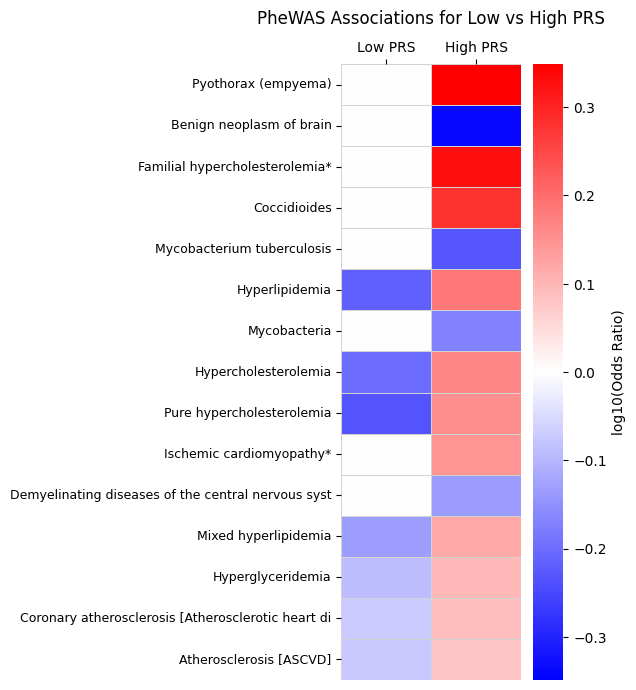

In [44]:
# --- select top signals ---
merged["total_strength"] = merged["Low PRS"].abs() + merged["High PRS"].abs()

plot_df = (
    merged
    .sort_values("total_strength", ascending=False)
    .head(15)
    .copy()
)

# optional: sort by High PRS effect for nicer ordering
plot_df = plot_df.sort_values(
    by="High PRS",
    key=lambda x: x.abs(),
    ascending=False
)

# build heatmap df
heatmap_df = plot_df.set_index("phecode_string")[["Low PRS", "High PRS"]]

# optional: shorten long labels
heatmap_df.index = heatmap_df.index.str.slice(0, 50)

# --- plot ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 8))

ax = sns.heatmap(
    heatmap_df,
    cmap="bwr",
    center=0,
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "log10(Odds Ratio)"},
    vmin=-heatmap_df.abs().max().max(),
    vmax=heatmap_df.abs().max().max()
)

ax.set_title("PheWAS Associations for Low vs High PRS", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=10, rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# fix spacing (better than tight_layout)
plt.subplots_adjust(left=0.45)

plt.show()

In [45]:
import numpy as np

top["neg_log10_p"] = -np.log10(top["p_value"])

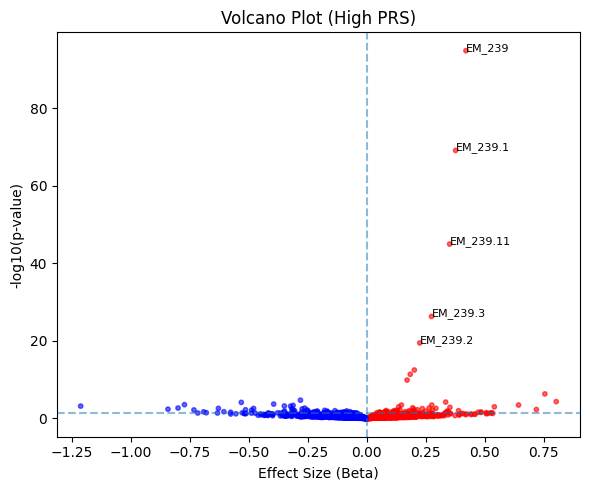

In [46]:
import matplotlib.pyplot as plt

# color by direction
colors = ["red" if b > 0 else "blue" for b in top["beta"]]

# plot
plt.figure(figsize=(6, 5))

plt.scatter(
    top["beta"],
    top["neg_log10_p"],
    c=colors,
    s=10,
    alpha=0.6
)

# significance + zero lines
plt.axhline(-np.log10(0.05), linestyle="--", alpha=0.5)
plt.axvline(0, linestyle="--", alpha=0.5)

# label top 10 points
top_sig = top.nsmallest(5, "p_value")

for _, row in top_sig.iterrows():
    plt.text(
        row["beta"],
        row["neg_log10_p"],
        row["phecode"],
        fontsize=8
    )

# labels
plt.xlabel("Effect Size (Beta)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot (High PRS)")

plt.tight_layout()
plt.savefig("volcano_high_prs.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
bottom["neg_log10_p"] = -np.log10(bottom["p_value"])

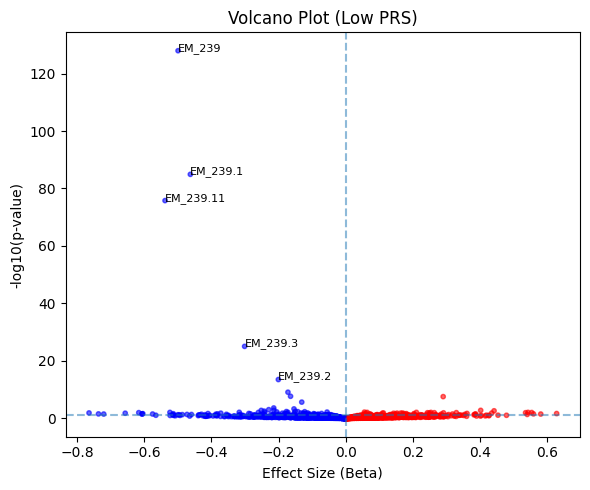

In [50]:
# color by direction
colors = ["red" if b > 0 else "blue" for b in bottom["beta"]]

# plot
plt.figure(figsize=(6, 5))

plt.scatter(
    bottom["beta"],
    bottom["neg_log10_p"],
    c=colors,
    s=10,
    alpha=0.6
)

# significance + zero lines
plt.axhline(-np.log10(0.05), linestyle="--", alpha=0.5)
plt.axvline(0, linestyle="--", alpha=0.5)

# label top 10 points
top_sig = bottom.nsmallest(5, "p_value")

for _, row in top_sig.iterrows():
    plt.text(
        row["beta"],
        row["neg_log10_p"],
        row["phecode"],
        fontsize=8
    )

# labels
plt.xlabel("Effect Size (Beta)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot (Low PRS)")


plt.tight_layout()
plt.savefig("volcano_low_prs.png", dpi=300, bbox_inches="tight")
plt.show()